# Stochastic GW spectrum from oscillons

Driver notebook for [`bssn/GWSignal.py`](../../bssn/GWSignal.py).

Implements the semi-analytical scheme of Antusch, Cefalà & Orani
([arXiv:1712.03231](https://arxiv.org/abs/1712.03231)) to compute the
stochastic gravitational-wave spectrum $\Omega_{\rm GW}(k)$ produced by
oscillons in our spherical-symmetry simulations, for both GR and
Einstein–scalar–Gauss–Bonnet (EsGB) gravity.

## Outline
1. Setup & path discovery.
2. Load one GR and one EsGB run, extract the parameters that feed the
   GW pipeline: $(A, R, \omega_{\rm source}, H_0)$.
3. **Equation-of-state sanity check.** The GW pipeline assumes
   $w = 0$ (matter domination, see Aurrekoetxea, Clough & Muia 2023 for
   this exact potential). The standalone diagnostic
   `check_equation_of_state` measures $w_{\rm eff}$ from $H(a)$ and warns
   if $|w_{\rm eff}| > 0.05$. Its output is purely informational.
4. Plot the source power spectrum $|\widetilde{\Phi^2}(\omega)|^2$ for both runs.
5. Compute and overlay $\Omega_{\rm GW}(k)$ for GR vs EsGB, with the ratio panel.
6. Fit the power-law $\Omega_{\rm GW} = A_{\rm GW}\,(k/\omega_s)^{n_{\rm GW}}$ and compare to the paper analytic scalings (sweep $w$ explicitly).
7. Apply analytic scaling relations ($\Omega \propto A^4$, $\Delta^2$, $N$).

All heavy lifting is delegated to `GWSignal.py`; this notebook is a
thin orchestration layer and is meant to be edited freely to play with
free parameters ($\Delta$, $N$, comoving volume $V$, etc.).

## 1 — Setup

In [1]:
import os, sys, importlib
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Project root so we can `from bssn.GWSignal import ...`
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import bssn.GWSignal as gw
importlib.reload(gw)  # pick up the latest edits when re-running
from bssn.GWSignal import (
    OscillonRun,
    Omega_GW,
    check_equation_of_state,
    compute_and_plot,
    compare_runs,
    plot_AGW_nGW_vs_w,
    AGW_of_w,
    nGW_of_w,
    Omega_GW_amplitude_scaling,
    Omega_GW_asymmetry_scaling,
    Omega_GW_N_scaling,
    find_run_dir,
    DEFAULT_DATA_DIR,
    DEFAULT_GR_TAG,
    DEFAULT_ESGB_TAG,
    DEFAULT_DELTA,
)

DATA_DIR = DEFAULT_DATA_DIR
print(f'DATA_DIR = {DATA_DIR}')
print(f'Default GR   tag = {DEFAULT_GR_TAG}')
print(f'Default EsGB tag = {DEFAULT_ESGB_TAG}')

DATA_DIR = /data/leuven/384/vsc38419/oscillon_runs
Default GR   tag = lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3_dr0.0625_quadratic_0
Default EsGB tag = lgb1.0_mu0.08_a0.0_b0.0_amp-0.02_R3.0_dr0.041666666666666664_quadratic_0


## 2 — Load runs and extract parameters

Edit `GR_TAG` / `ESGB_TAG` to compare any other pair of runs.

The pipeline extracts $(A, R, \omega_{\rm source}, H_0)$ from each run.
**The equation of state $w$ is hard-coded to $0$** (matter domination)
in all subsequent GW computations — it is *not* fitted from $H(a)$.
The next cell runs a standalone sanity check on this assumption.

In [2]:
# Select which runs you want to compare
"""
GR_TAG   = DEFAULT_GR_TAG
ESGB_TAG = DEFAULT_ESGB_TAG
"""
GR_TAG   = DEFAULT_GR_TAG
ESGB_TAG = "lgb0_mu0.08_a0_b0_amp-0.02_R3_dr0.0416667_quadratic_g220"


STABLE_WINDOW = (2.0, 3.6)   # ln(a/a0) window for parameter extraction

gr_run   = OscillonRun(find_run_dir(GR_TAG,   DATA_DIR), label='GR',   stable_window=STABLE_WINDOW)
esgb_run = OscillonRun(find_run_dir(ESGB_TAG, DATA_DIR), label='EsGB', stable_window=STABLE_WINDOW)

print('--- GR ---')
params_GR = gr_run.extract_all(verbose=True)
print('\n--- EsGB ---')
params_EsGB = esgb_run.extract_all(verbose=True)

--- GR ---
[GR]
  A             = 2.7347e-01
  R             = 9.6595  (1/m)
  omega_source  = 0.0813  (m)
  w             = +0.000   (assumed; not fitted -- see check_equation_of_state)
  H0            = 4.1458e-03  (m)

--- EsGB ---
[EsGB]
  A             = 3.1195e-01
  R             = 7.6457  (1/m)
  omega_source  = 0.8748  (m)
  w             = +0.000   (assumed; not fitted -- see check_equation_of_state)
  H0            = 5.3755e-03  (m)


## 3 — Equation-of-state sanity check

Verify that the matter-domination assumption ($w = 0$) used by `Omega_GW`
is justified for each run. The diagnostic computes
$$
w_{\rm eff} = -1 - \tfrac{2}{3}\,\frac{d \ln H}{d \ln a},
$$
fitted across the stable oscillon window (which spans many oscillation
cycles), and prints a warning if $|w_{\rm eff}| > 0.05$.

This is purely informational: the result is **not** plumbed back into
the GW calculation. If you want to override $w$, pass it explicitly to
`Omega_GW(..., w=w_eff)`.

In [3]:
print('--- GR ---')
eos_GR = check_equation_of_state(gr_run, n_cycles=5, tol=0.05)
print('\n--- EsGB ---')
eos_EsGB = check_equation_of_state(esgb_run, n_cycles=5, tol=0.05)

if eos_GR['warning'] or eos_EsGB['warning']:
    print('\n[Warning] At least one run shows |w_eff| > 0.05.')
    print('          Consider overriding w in Omega_GW for that run.')
else:
    print('\nBoth runs are consistent with matter domination (|w_eff| <= 0.05).')

--- GR ---
[check_equation_of_state] GR
  stable window      = ln a in (2.0, 3.6)
  H0 (start of win.) = 4.1458e-03  m
  d ln H / d ln a    = -1.1758
  w_eff (global fit) = -0.2161   (R^2 = 1.000)
  w_eff (local)      = -0.2175  +/- 0.0022   (387 sliding windows of ~5.0 cycles)

--- EsGB ---
[check_equation_of_state] EsGB
  stable window      = ln a in (2.0, 3.6)
  H0 (start of win.) = 5.3755e-03  m
  d ln H / d ln a    = -1.0204
  w_eff (global fit) = -0.3198   (R^2 = 1.000)
  w_eff (local)      = -0.3209  +/- 0.0048   (764 sliding windows of ~5.0 cycles)

[Warning] At least one run shows |w_eff| > 0.05.
          Consider overriding w in Omega_GW for that run.


## 4 — Source power spectrum $|\widetilde{\Phi^2}(\omega)|^2$

Locates the dominant frequency $\omega_{\rm source}$ (where the GW peak
will sit) and any subdominant harmonics. For our asymmetric inflaton
potential the peak is at $\omega_{\rm osc}$ itself (the paper's symmetric
potential gives a peak at $2\omega_{\rm osc}$).

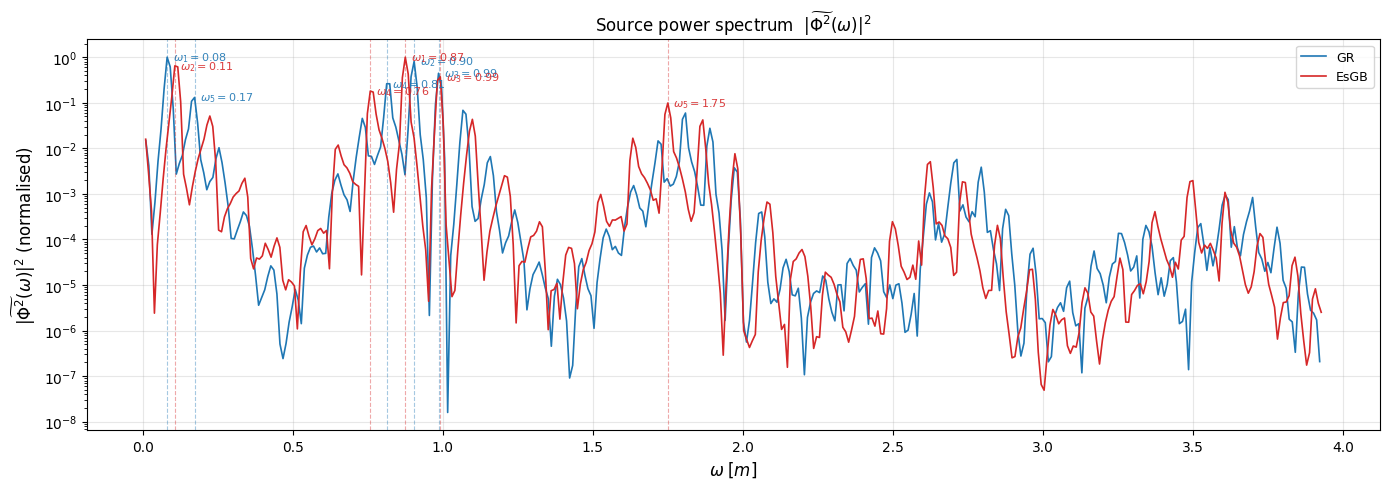


GR harmonics:
  omega_1 = 0.0813,  A_n/A_1 = 1.000,  GW weight (A_n/A_1)^4 = 1.0000
  omega_2 = 0.9043,  A_n/A_1 = 0.899,  GW weight (A_n/A_1)^4 = 0.6520
  omega_3 = 0.9856,  A_n/A_1 = 0.667,  GW weight (A_n/A_1)^4 = 0.1975
  omega_4 = 0.8128,  A_n/A_1 = 0.512,  GW weight (A_n/A_1)^4 = 0.0685
  omega_5 = 0.1727,  A_n/A_1 = 0.362,  GW weight (A_n/A_1)^4 = 0.0172

EsGB harmonics:
  omega_1 = 0.8748,  A_n/A_1 = 1.000,  GW weight (A_n/A_1)^4 = 1.0000
  omega_2 = 0.1069,  A_n/A_1 = 0.805,  GW weight (A_n/A_1)^4 = 0.4191
  omega_3 = 0.9915,  A_n/A_1 = 0.608,  GW weight (A_n/A_1)^4 = 0.1369
  omega_4 = 0.7582,  A_n/A_1 = 0.425,  GW weight (A_n/A_1)^4 = 0.0328
  omega_5 = 1.7496,  A_n/A_1 = 0.314,  GW weight (A_n/A_1)^4 = 0.0098


In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
gr_run.plot_source_power_spectrum(ax=ax, color='C0')
esgb_run.plot_source_power_spectrum(ax=ax, color='C3')
ax.set_title(r'Source power spectrum  $|\widetilde{\Phi^2}(\omega)|^2$')
fig.tight_layout()
plt.show()

for run, label in [(gr_run, 'GR'), (esgb_run, 'EsGB')]:
    omegas, amps, peaks = run.fft_source_spectrum(n_harmonics=5)
    A_dominant = peaks[0, 1]  # amplitude of dominant peak
    print(f"\n{label} harmonics:")
    for i, (omega_n, amp_n) in enumerate(peaks):
        ratio = (amp_n / A_dominant) ** 0.5  # sqrt because amps are power
        print(f"  omega_{i+1} = {omega_n:.4f},  A_n/A_1 = {ratio:.3f},  "
              f"GW weight (A_n/A_1)^4 = {ratio**4:.4f}")

In the case that the harmonics are comparable to the dominant mode, these should be taken into account and 'cosine mode' (which only takes the primary frequency into account), should NOT BE USED, but harmonics mode should be used.

## 5 — $\Omega_{\rm GW}(k)$: GR vs EsGB, Only primary mode

Free parameters of the model (paper Sec. 4.2):
* `Delta` — oscillon asymmetry (default 0.3),
* `N` — number of oscillons in the comoving box,
* `V` — comoving volume of the box (default $(100 R)^3$),
* `n_angles`, `n_tau` — numerical resolutions of the $d\Omega$ and $d\tau'$ integrals.

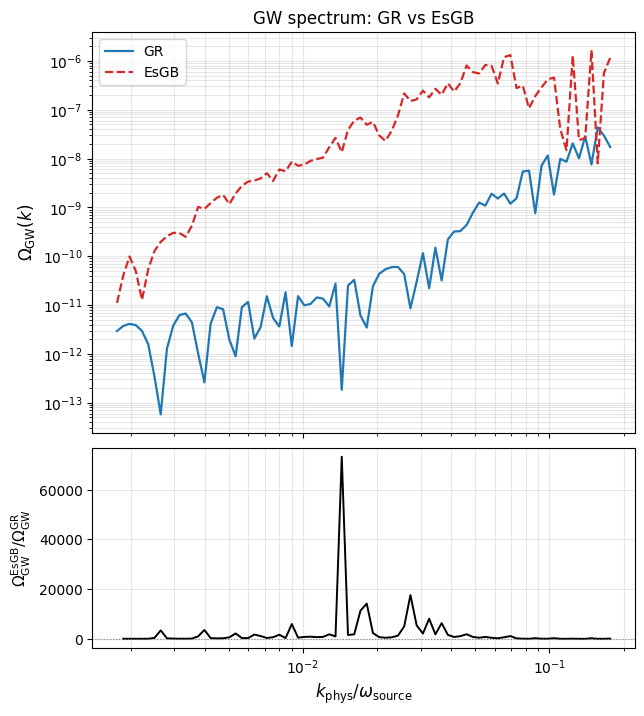


GR   peak: k_phys/omega_s = 0.157, Omega_max = 4.345e-08
EsGB peak: k_phys/omega_s = 0.148, Omega_max = 1.658e-06


In [5]:
Delta    = DEFAULT_DELTA   # oscillon asymmetry
N_OSC    = 1               # number of oscillons in the box
N_ANGLES = 60              # 20-50 is a good range; 16 is fast for sanity check
N_TAU    = 1000             # number of conformal-time samples
SEED     = 42              # shared seed -> identical positions/phases for both runs

fig, axes, (res_GR, res_EsGB) = compare_runs(
    gr_run, esgb_run,
    labels=('GR', 'EsGB'),
    Delta=Delta, N=N_OSC, seed=SEED,
    spec_kwargs=dict(n_angles=N_ANGLES, n_tau=N_TAU),
)
plt.show()

print(f"\nGR   peak: k_phys/omega_s = {res_GR['peak_k']  /params_GR['omega_source']:.3f}, "
      f"Omega_max = {np.nanmax(res_GR['Omega_GW']):.3e}")
print(f"EsGB peak: k_phys/omega_s = {res_EsGB['peak_k']/params_EsGB['omega_source']:.3f}, "
      f"Omega_max = {np.nanmax(res_EsGB['Omega_GW']):.3e}")

# GR vS EsGB: different a_f

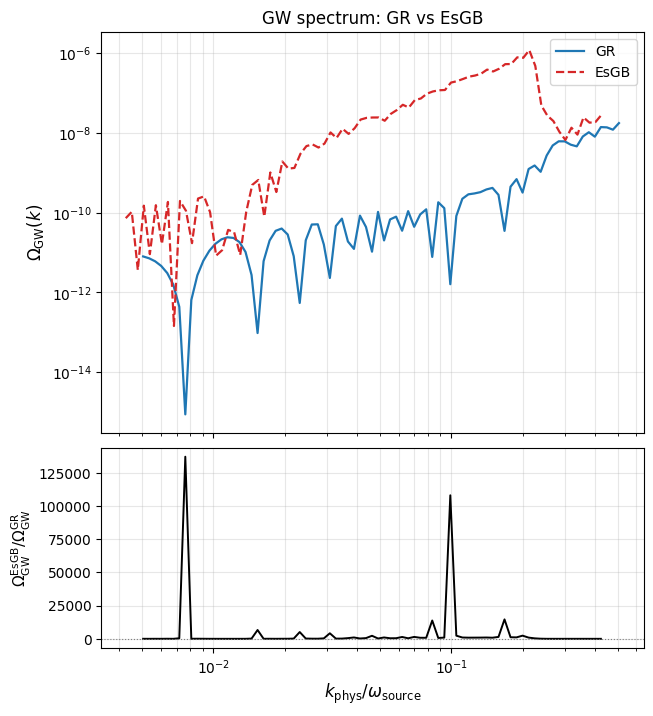


Integration window: t in [0, 20/H0_ref]  (H0_ref = 4.146e-03)
  a_f(GR)   = 9.868
  a_f(EsGB) = 11.676

GR   peak: k_phys/omega_s = 0.507, Omega_max = 1.742e-08
EsGB peak: k_phys/omega_s = 0.213, Omega_max = 1.172e-06


In [20]:
Delta     = DEFAULT_DELTA   # oscillon asymmetry
N_OSC     = 1               # number of oscillons in the box
N_ANGLES  = 20              # 20-50 is a good range; 16 is fast for sanity check
N_TAU     = 500            # number of conformal-time samples
SEED      = 42              # shared seed -> identical positions/phases for both runs
N_HUBBLE  = 20.0            # length of integration window in Hubble times (was 100 internally -> a_f ~ 28)

# tau_window is shared by both runs, so use the smaller H0 (longer cosmic time) so neither run is truncated early.
H0_REF     = min(params_GR['H0'], params_EsGB['H0'])
TAU_WINDOW = (0.0, N_HUBBLE / H0_REF)

fig, axes, (res_GR, res_EsGB) = compare_runs(
    gr_run, esgb_run,
    labels=('GR', 'EsGB'),
    Delta=Delta, N=N_OSC, seed=SEED,
    spec_kwargs=dict(
        n_angles=N_ANGLES,
        n_tau=N_TAU,
        tau_window=TAU_WINDOW,
    ),
)
plt.show()

print(f"\nIntegration window: t in [0, {N_HUBBLE:.0f}/H0_ref]  (H0_ref = {H0_REF:.3e})")
print(f"  a_f(GR)   = {res_GR['a_f']:.3f}")
print(f"  a_f(EsGB) = {res_EsGB['a_f']:.3f}")

print(f"\nGR   peak: k_phys/omega_s = {res_GR['peak_k']  /params_GR['omega_source']:.3f}, "
      f"Omega_max = {np.nanmax(res_GR['Omega_GW']):.3e}")
print(f"EsGB peak: k_phys/omega_s = {res_EsGB['peak_k']/params_EsGB['omega_source']:.3f}, "
      f"Omega_max = {np.nanmax(res_EsGB['Omega_GW']):.3e}")

# GR Vs EsGB with different $a_f$

## Play a bit with these parameters

In [ ]:
N_HUBBLE_GR = 10.0
N_HUBBLE_ESGB = 10.0

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 5))

ax, res_GR = compute_and_plot(
    gr_run,  ax=ax, color="C0", label="GR",
    Delta=Delta, N=N_OSC,
    spec_kwargs=dict(
        n_angles=N_ANGLES, n_tau=N_TAU, seed=SEED,
        tau_window=(0.0, N_HUBBLE_GR / params_GR['H0']),   # <-- per-run
    ),
)

ax, res_EsGB = compute_and_plot(
    esgb_run, ax=ax, color="C3", label="EsGB",
    Delta=Delta, N=N_OSC,
    spec_kwargs=dict(
        n_angles=N_ANGLES, n_tau=N_TAU, seed=SEED,
        tau_window=(0.0, N_HUBBLE_ESGB / params_EsGB['H0']),  # <-- per-run
    ),
)
plt.show()

print(f"a_f(GR)   = {res_GR['a_f']:.3f}")
print(f"a_f(EsGB) = {res_EsGB['a_f']:.3f}")    # should now match GR

NameError: name 'Delta' is not defined

# CURRENTLY DOIN THE CELL BELOW HERE:

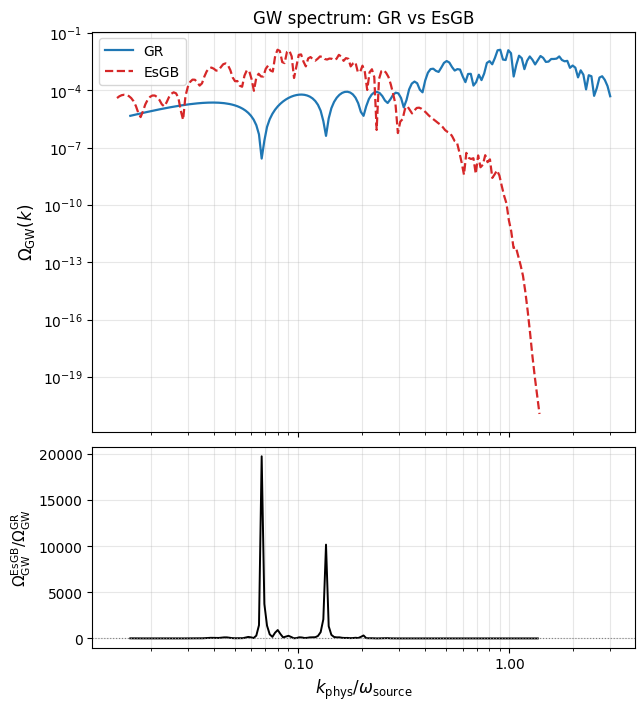

In [14]:
Delta    = DEFAULT_DELTA
N_OSC    = 1
N_ANGLES = 60
N_TAU    = 2000
SEED     = 42
N_HUBBLE = 3
N_K      = 180

H0_REF     = min(params_GR['H0'], params_EsGB['H0'])
TAU_WINDOW = (0.0, N_HUBBLE / H0_REF)

# Final scale factor for the matter-dominated background (w=0, eq. 4.13):
#   a(t) = (9/4)^{1/3} * (2/3 + H0 t)^{2/3}
def _a_final_matter(H0, t_end):
    return (9.0 / 4.0) ** (1.0 / 3.0) * (2.0 / 3.0 + H0 * t_end) ** (2.0 / 3.0)

a_f_GR = _a_final_matter(params_GR['H0'], TAU_WINDOW[1])

# The Gaussian TT-envelope in eq. 3.10 suppresses modes with k_phys R / (2 a) > 1,
# so the UV cutoff in normalized units sits near k_phys/omega_s ~ 2/(omega_s R):
# ~2.5 for GR (omega_s R = 0.785) and ~0.3 for EsGB (omega_s R = 6.69).
# Push the GR k-grid out to k_phys/omega_s = 3.0 to expose the GR UV suppression.
# EsGB keeps the default k_max = 5 * omega_source (its cutoff is well within range).
K_PHYS_MAX_GR = 3.0

k_grid_GR = np.logspace(
    np.log10(0.05 * params_GR['omega_source']),
    np.log10(K_PHYS_MAX_GR * params_GR['omega_source'] * a_f_GR),
    N_K,
)
k_grid_EsGB = np.logspace(
    np.log10(0.05 * params_EsGB['omega_source']),
    np.log10(5.0  * params_EsGB['omega_source']),
    N_K,
)

common_kwargs = dict(
    n_angles=N_ANGLES,
    n_tau=N_TAU,
    tau_window=TAU_WINDOW,
    harmonics="fourier",
    fourier_modes=[(float(o), float(a), 0.0) for o, a in gr_run.harmonics],
)

res_GR = Omega_GW(
    A=params_GR['A'], R=params_GR['R'],
    omega_source=params_GR['omega_source'], H0=params_GR['H0'],
    Delta=Delta, N=N_OSC, seed=SEED,
    k_grid=k_grid_GR, **common_kwargs,
)
res_EsGB = Omega_GW(
    A=params_EsGB['A'], R=params_EsGB['R'],
    omega_source=params_EsGB['omega_source'], H0=params_EsGB['H0'],
    Delta=Delta, N=N_OSC, seed=SEED,
    k_grid=k_grid_EsGB, **common_kwargs,
)

fig, axes = plt.subplots(
    2, 1, figsize=(7, 8),
    gridspec_kw=dict(height_ratios=[3, 1.5], hspace=0.05),
    sharex=True,
)
ax_top, ax_bot = axes

x_GR   = res_GR['k_phys']   / params_GR['omega_source']
x_EsGB = res_EsGB['k_phys'] / params_EsGB['omega_source']

ax_top.loglog(x_GR,   res_GR['Omega_GW'],   'C0-',  lw=1.6, label='GR')
ax_top.loglog(x_EsGB, res_EsGB['Omega_GW'], 'C3--', lw=1.6, label='EsGB')
ax_top.set_ylabel(r'$\Omega_{\rm GW}(k)$', fontsize=12)
ax_top.set_title(r'GW spectrum: GR vs EsGB')
ax_top.grid(True, alpha=0.3, which='both')
ax_top.legend(fontsize=10)

Omega_EsGB_on_GR = np.interp(x_GR, x_EsGB, res_EsGB['Omega_GW'],
                             left=np.nan, right=np.nan)
ratio = Omega_EsGB_on_GR / np.where(res_GR['Omega_GW'] > 0,
                                    res_GR['Omega_GW'], np.nan)
ax_bot.semilogx(x_GR, ratio, 'k-', lw=1.4)
ax_bot.axhline(1.0, color='grey', ls=':', lw=0.8)
ax_bot.set_xlabel(r'$k_{\rm phys}/\omega_{\rm source}$', fontsize=12)
ax_bot.set_ylabel(r'$\Omega_{\rm GW}^{\rm EsGB}/\Omega_{\rm GW}^{\rm GR}$',
                  fontsize=11)
ax_bot.grid(True, alpha=0.3, which='both')

from matplotlib.ticker import ScalarFormatter
for ax in axes:
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_formatter(plt.NullFormatter())

plt.show()

# NEW NEW THIS WILL WORK

<>:156: SyntaxWarning: invalid escape sequence '\o'
<>:156: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_782708/2815966464.py:156: SyntaxWarning: invalid escape sequence '\o'
  """


a_f (GR)   = 3.12
a_f (EsGB) = 3.12

omega*R (GR)   = 0.785  ->  UV cutoff at k_phys/omega ~ 2.55
omega*R (EsGB) = 6.689  ->  UV cutoff at k_phys/omega ~ 0.30

Running GR spectrum ...
Running EsGB spectrum ...


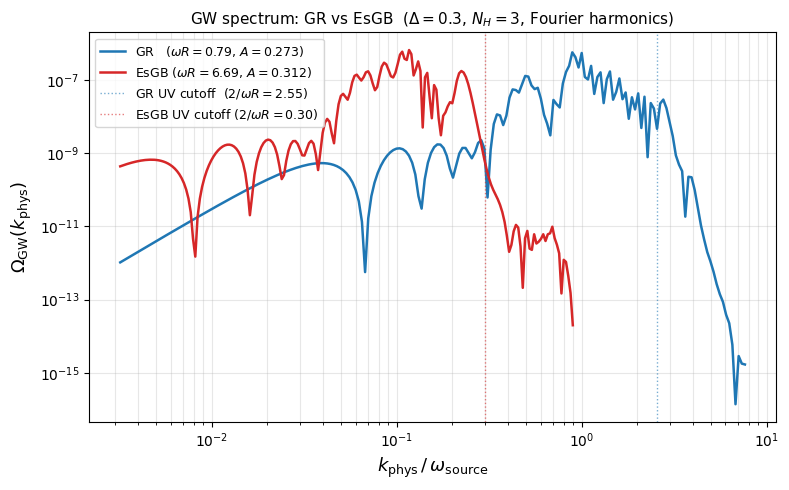


GR   peak: k_phys/omega = 0.891,  Omega_max = 5.582e-07
EsGB peak: k_phys/omega = 0.117,  Omega_max = 6.451e-07

Fourier modes used:
  GR   : [(0.08128312169701922, 0.2734662364355326, 0.0), (0.9042747288793387, 0.24573333225393185, 0.0), (0.985557850576358, 0.1823013071972998, 0.0), (0.8128312169701923, 0.13988408602791624, 0.0), (0.17272663360616586, 0.0989825067229465, 0.0)]
  EsGB : [(0.8748246869526032, 0.31194567068059226, 0.0), (0.10692301729420706, 0.2509905131477981, 0.0), (0.9914679785462835, 0.18975082829592327, 0.0), (0.7581813953589227, 0.13271619609687785, 0.0), (1.7496493739052064, 0.09805081880937583, 0.0)]


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from bssn.GWSignal import Omega_GW, background_a_of_t, DEFAULT_DELTA

# ─────────────────────────────────────────────────────────────
# Parameters
# ─────────────────────────────────────────────────────────────
Delta    = DEFAULT_DELTA
N_OSC    = 1
N_ANGLES = 20
N_TAU    = 500
SEED     = 42

################
#N_HUBBLE = 20.0
# How many hubble times does the oscillon live ? 
N_HUBBLE = 3

params_GR = dict(
    A            = gr_run.A,
    R            = gr_run.R,
    omega_source = gr_run.omega_source,
    H0           = gr_run.H0,
    w            = 0.0,
)
params_EsGB = dict(
    A            = esgb_run.A,
    R            = esgb_run.R,
    omega_source = esgb_run.omega_source,
    H0           = esgb_run.H0,
    w            = 0.0,
)

# Fourier modes from FFT of each run # OLD UNNORMALIZED FOURIER MODES
#fourier_modes_GR   = [(float(o), float(a), 0.0) for o, a in gr_run.harmonics]
#fourier_modes_EsGB = [(float(o), float(a), 0.0) for o, a in esgb_run.harmonics]

# CORRECT - normalizes to physical field amplitude
def build_fourier_modes(run):
    peaks  = run.harmonics       # (omega, raw_fft_power) — raw power, NOT field amplitude
    A_phys = run.A               # physical field amplitude from simulation
    p_dom  = float(peaks[0, 1]) # raw power of dominant mode
    return [
        (float(omega_n), float(A_phys * np.sqrt(float(power_n) / p_dom)), 0.0)
        for omega_n, power_n in peaks
    ]

fourier_modes_GR   = build_fourier_modes(gr_run)
fourier_modes_EsGB = build_fourier_modes(esgb_run)


# ─────────────────────────────────────────────────────────────
# Separate integration windows per run, each run uses its own H0
# ─────────────────────────────────────────────────────────────
tau_window_GR   = (0.0, N_HUBBLE / params_GR['H0'])
tau_window_EsGB = (0.0, N_HUBBLE / params_EsGB['H0'])

# Final scale factors
def a_final(H0, tau_end, w=0.0, n=5000):
    t = np.linspace(0.0, tau_end, n)
    return float(background_a_of_t(t, w, H0)[-1])

a_f_GR   = a_final(params_GR['H0'],   tau_window_GR[1])
a_f_EsGB = a_final(params_EsGB['H0'], tau_window_EsGB[1])

print(f"a_f (GR)   = {a_f_GR:.2f}")
print(f"a_f (EsGB) = {a_f_EsGB:.2f}")

# ─────────────────────────────────────────────────────────────
# k-grids tuned to each run
#
# UV cutoff in absolute units: k_phys_cut ~ 2/R  (Gaussian envelope)
# UV cutoff in normalised units: k_phys/omega ~ 2/(omega*R)
#
# We set k_max to 1.5 * (2/R) * a_f in comoving units
#kmaxxer = 1.5
kmaxxer = 3
# to ensure the full UV suppression is visible.
# IR: start at 0.01 * omega_source to capture the full IR rise.
# ─────────────────────────────────────────────────────────────
N_K = 200

oR_GR   = params_GR['omega_source']   * params_GR['R']
oR_EsGB = params_EsGB['omega_source'] * params_EsGB['R']

print(f"\nomega*R (GR)   = {oR_GR:.3f}  ->  UV cutoff at k_phys/omega ~ {2/oR_GR:.2f}")
print(f"omega*R (EsGB) = {oR_EsGB:.3f}  ->  UV cutoff at k_phys/omega ~ {2/oR_EsGB:.2f}")

# comoving k_max = physical_k_max * a_f
# physical k_max = 1.5 * (2/R)  to comfortably show the UV drop
k_max_phys_GR   = kmaxxer * (2.0 / params_GR['R'])
k_max_phys_EsGB = kmaxxer * (2.0 / params_EsGB['R'])

k_grid_GR = np.logspace(
    np.log10(0.01 * params_GR['omega_source']),
    np.log10(k_max_phys_GR * a_f_GR),
    N_K,
)
k_grid_EsGB = np.logspace(
    np.log10(0.01 * params_EsGB['omega_source']),
    np.log10(k_max_phys_EsGB * a_f_EsGB),
    N_K,
)

# ─────────────────────────────────────────────────────────────
# Compute spectra
# ─────────────────────────────────────────────────────────────
print("\nRunning GR spectrum ...")
res_GR = Omega_GW(
    **params_GR,
    Delta         = Delta,
    N             = N_OSC,
    n_angles      = N_ANGLES,
    n_tau         = N_TAU,
    k_grid        = k_grid_GR,
    tau_window    = tau_window_GR,
    seed          = SEED,
    harmonics     = "fourier",
    fourier_modes = fourier_modes_GR,
)

print("Running EsGB spectrum ...")
res_EsGB = Omega_GW(
    **params_EsGB,
    Delta         = Delta,
    N             = N_OSC,
    n_angles      = N_ANGLES,
    n_tau         = N_TAU,
    k_grid        = k_grid_EsGB,
    tau_window    = tau_window_EsGB,
    seed          = SEED,
    # Change how you want the modes to play a role
    harmonics     = "fourier",
    fourier_modes = fourier_modes_EsGB,
)

# ─────────────────────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────────────────────
x_GR   = res_GR['k_phys']   / params_GR['omega_source']
x_EsGB = res_EsGB['k_phys'] / params_EsGB['omega_source']

fig, ax = plt.subplots(figsize=(8, 5))

ax.loglog(x_GR,   res_GR['Omega_GW'],   'C0-',  lw=1.8,
          label=rf'GR   ($\omega R={oR_GR:.2f}$, $A={params_GR["A"]:.3f}$)')
ax.loglog(x_EsGB, res_EsGB['Omega_GW'], 'C3-', lw=1.8,
          label=rf'EsGB ($\omega R={oR_EsGB:.2f}$, $A={params_EsGB["A"]:.3f}$)')

# Mark UV cutoffs (vertical lines at k_phys/omega = 2/(omega*R))
ax.axvline(2.0 / oR_GR,   color='C0', ls=':', lw=1.0, alpha=0.6,
           label=rf'GR UV cutoff  ($2/\omega R={2/oR_GR:.2f}$)')
ax.axvline(2.0 / oR_EsGB, color='C3', ls=':', lw=1.0, alpha=0.6,
           label=rf'EsGB UV cutoff ($2/\omega R={2/oR_EsGB:.2f}$)')

"""         
# Mark dominant emission peaks (k_phys ~ omega_source, so k_phys/omega_source ~ 1)
# For cosine mode: source oscillates at 2*omega, so peak at k_phys/omega = 2
# For Fourier mode with asymmetric potential: dominant peak at k_phys/omega = 1
ax.axvline(1.0, color='C0', ls='--', lw=1.0, alpha=0.6,
           label=rf'GR emission peak ($\omega_1={params_GR["omega_source"]:.3f}$)')
ax.axvline(1.0, color='C3', ls='--', lw=1.0, alpha=0.6,
           label=rf'EsGB emission peak ($\omega_1={params_EsGB["omega_source"]:.3f}$)')
"""
ax.set_xlabel(r'$k_{\rm phys}\,/\,\omega_{\rm source}$', fontsize=13)
ax.set_ylabel(r'$\Omega_{\rm GW}(k_{\rm phys})$',        fontsize=13)
ax.set_title(
    rf'GW spectrum: GR vs EsGB  '
    rf'($\Delta={Delta}$, $N_H={N_HUBBLE:.0f}$, Fourier harmonics)',
    fontsize=11,
)
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# ─────────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────────
print(f"\nGR   peak: k_phys/omega = {res_GR['peak_k']   / params_GR['omega_source']:.3f},  "
      f"Omega_max = {res_GR['Omega_GW'].max():.3e}")
print(f"EsGB peak: k_phys/omega = {res_EsGB['peak_k'] / params_EsGB['omega_source']:.3f},  "
      f"Omega_max = {res_EsGB['Omega_GW'].max():.3e}")
print(f"\nFourier modes used:")
print(f"  GR   : {fourier_modes_GR}")
print(f"  EsGB : {fourier_modes_EsGB}")

## 6 — Power-law fit $A_{\rm GW}(w)$, $n_{\rm GW}(w)$ vs paper analytics

Since $w$ is hard-coded to $0$ in the GW pipeline, the runs themselves
all sit at the same $w$. To compare with the analytic fits eqs. 4.18–4.21
of the paper we explicitly **sweep** $w$ in `Omega_GW` (this is purely a
theoretical exploration; the physical runs only correspond to the $w=0$
point).

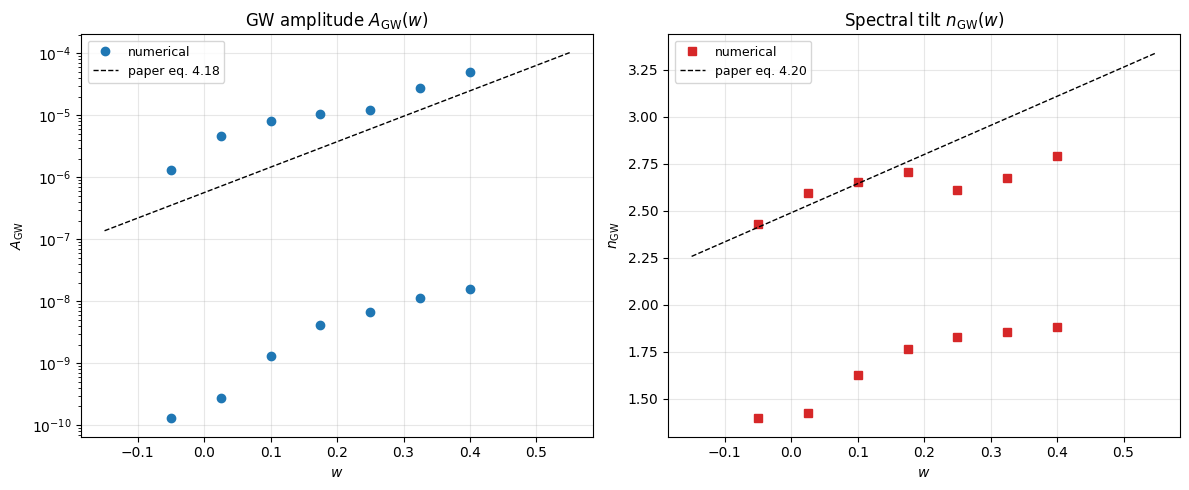

Numerical fits (one per (run, w) pair):
                    GR (w=-0.05): w = -0.050, A_GW = 1.329e-06, n_GW = 2.427
                    GR (w=+0.02): w = +0.025, A_GW = 4.614e-06, n_GW = 2.594
                    GR (w=+0.10): w = +0.100, A_GW = 8.208e-06, n_GW = 2.651
                    GR (w=+0.17): w = +0.175, A_GW = 1.067e-05, n_GW = 2.706
                    GR (w=+0.25): w = +0.250, A_GW = 1.206e-05, n_GW = 2.613
                    GR (w=+0.33): w = +0.325, A_GW = 2.800e-05, n_GW = 2.675
                    GR (w=+0.40): w = +0.400, A_GW = 4.973e-05, n_GW = 2.792
                  EsGB (w=-0.05): w = -0.050, A_GW = 1.282e-10, n_GW = 1.395
                  EsGB (w=+0.02): w = +0.025, A_GW = 2.720e-10, n_GW = 1.425
                  EsGB (w=+0.10): w = +0.100, A_GW = 1.328e-09, n_GW = 1.625
                  EsGB (w=+0.17): w = +0.175, A_GW = 4.194e-09, n_GW = 1.764
                  EsGB (w=+0.25): w = +0.250, A_GW = 6.784e-09, n_GW = 1.829
                  EsGB (w=+0.33): w 

In [6]:
w_sweep = np.linspace(-0.05, 0.40, 7)

fig, axes, summary = plot_AGW_nGW_vs_w(
    [gr_run, esgb_run],
    w_values=w_sweep,
    Delta=Delta, N=N_OSC,
    spec_kwargs=dict(n_angles=N_ANGLES, n_tau=N_TAU),
)
plt.show()

print('Numerical fits (one per (run, w) pair):')
for w_, A_, n_, l_ in zip(summary['w'], summary['A_GW'], summary['n_GW'], summary['labels']):
    print(f'  {l_:>30s}: w = {w_:+.3f}, A_GW = {A_:.3e}, n_GW = {n_:.3f}')

print('\nPaper analytic at w = 0 (the value used by the GW pipeline):')
print(f'  A_GW(w=0) = {AGW_of_w(0.0):.3e}, n_GW(w=0) = {nGW_of_w(0.0):.3f}')

## 7 — Analytic scaling helpers (Sec. 4 of the paper)

Cheap predictions for parameter sweeps without re-running the full integral:
$\Omega_{\rm GW} \propto A^4$, $\Omega_{\rm GW} \propto \Delta^2$,
$\Omega_{\rm GW} \propto N$ (incoherent random phases).

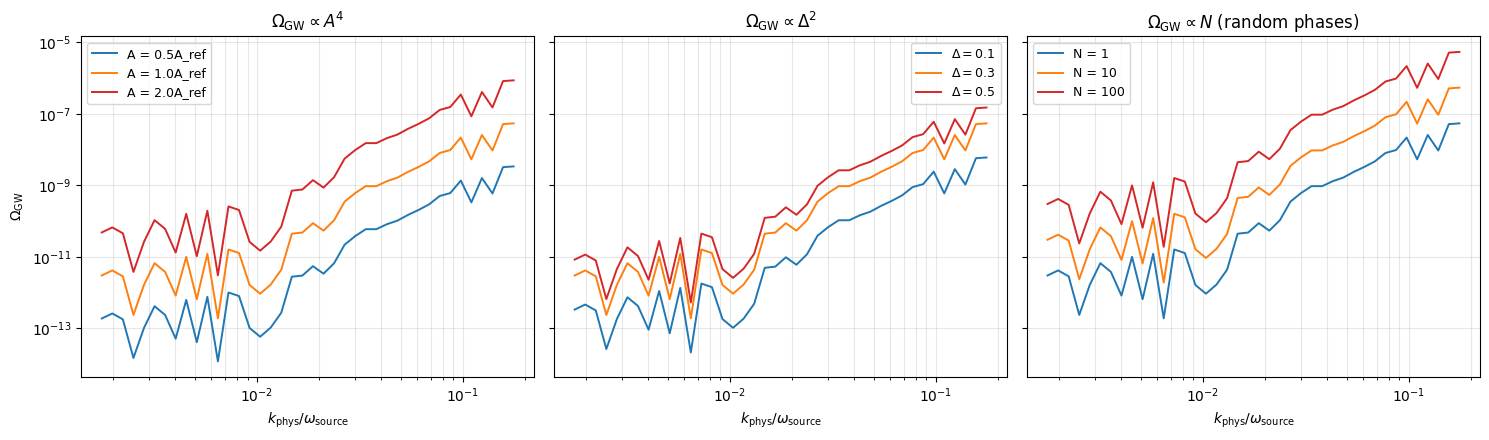

In [7]:
Omega_ref = res_GR['Omega_GW']
k_phys_norm = res_GR['k_phys'] / params_GR['omega_source']

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

# Amplitude scaling: A -> 0.5 A, A, 2 A
ax = axes[0]
for fac, c in zip([0.5, 1.0, 2.0], ['C0', 'C1', 'C3']):
    ax.loglog(k_phys_norm,
              Omega_GW_amplitude_scaling(Omega_ref, fac * params_GR['A'], params_GR['A']),
              color=c, lw=1.4, label=f'A = {fac}A_ref')
ax.set_title(r'$\Omega_{\rm GW} \propto A^4$')
ax.set_xlabel(r'$k_{\rm phys}/\omega_{\rm source}$'); ax.set_ylabel(r'$\Omega_{\rm GW}$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')

# Asymmetry scaling: Delta -> 0.1, 0.3, 0.5
ax = axes[1]
for d, c in zip([0.1, 0.3, 0.5], ['C0', 'C1', 'C3']):
    ax.loglog(k_phys_norm,
              Omega_GW_asymmetry_scaling(Omega_ref, d, Delta),
              color=c, lw=1.4, label=fr'$\Delta = {d}$')
ax.set_title(r'$\Omega_{\rm GW} \propto \Delta^2$')
ax.set_xlabel(r'$k_{\rm phys}/\omega_{\rm source}$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')

# N scaling: N = 1, 10, 100
ax = axes[2]
for n, c in zip([1, 10, 100], ['C0', 'C1', 'C3']):
    ax.loglog(k_phys_norm,
              Omega_GW_N_scaling(Omega_ref, n, N_OSC),
              color=c, lw=1.4, label=f'N = {n}')
ax.set_title(r'$\Omega_{\rm GW} \propto N$ (random phases)')
ax.set_xlabel(r'$k_{\rm phys}/\omega_{\rm source}$')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3, which='both')

fig.tight_layout()
plt.show()

## 8 — Single-run plot (template for any other run)

Use this cell to compute and visualise $\Omega_{\rm GW}(k)$ for any single
run loaded above. Replace `gr_run` with `esgb_run` (or any other
`OscillonRun` instance) as needed.

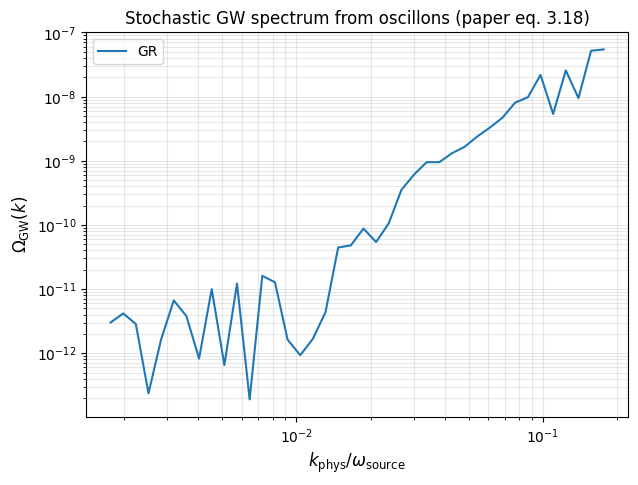

peak  k_phys = 0.0143  (omega_source = 0.0813)
A_GW = 2.375e-06, n_GW = 2.527


In [8]:
ax, res = compute_and_plot(
    gr_run,
    Delta=Delta, N=N_OSC,
    spec_kwargs=dict(n_angles=N_ANGLES, n_tau=N_TAU),
)
plt.show()
print(f"peak  k_phys = {res['peak_k']:.4f}  (omega_source = {params_GR['omega_source']:.4f})")
print(f"A_GW = {res['A_GW']:.3e}, n_GW = {res['n_GW']:.3f}")

## 9 — Benchmark against the paper (reproduce Fig. 2)

Validation step: bypass `OscillonRun` entirely and feed `Omega_GW` the
**paper's own default parameters** (Antusch–Cefalà–Orani 2017, eqs. 4.6–4.7):

$$
A = 0.05\,m_{\rm Pl},\quad
\omega_{\rm osc}/m_{\rm Pl} = m_{\rm Pl} R = 1,\quad
H_0 \simeq 0.002\,m_{\rm Pl},\quad
\mathcal V = (100\,R)^3,\quad
N=1,\quad w=0,\quad a_f = 3.
$$

We sweep $\Delta \in \{0.1, 0.2, 0.3, 0.4\}$ and reproduce **Fig. 2** of the paper.
Two checks:

1. **Visual** — the four curves should look like Fig. 2: same peak position
   in $k_{\rm phys}/\omega_{\rm osc}$, amplitude scaling with $\Delta$.
2. **Quantitative** — the paper's eq. 4.12 predicts
   $\Omega_{\rm GW}\propto\Delta^2$, so $\max(\Omega)$ at $\Delta=0.4$ should
   be $\approx (0.4/0.1)^2 = 16$ times that at $\Delta=0.1$.

If both pass, the pipeline is validated and any difference our actual runs
show vs the paper is *physics* (different $A,R,\omega_{\rm source},H_0,w$),
not a bug.

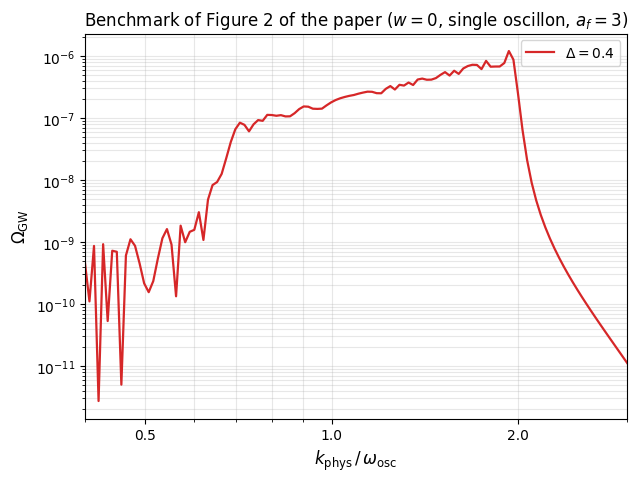

'\n# Quantitative check: Omega_GW propto Delta^2 (paper eq. 4.12)\nprint(f"a_f reached: {results_bench[0.1][\'a_f\']:.3f}  (target = {A_F_TARGET})")\nprint()\nprint(f"{\'Delta\':>6} {\'max(Omega_GW)\':>16} {\'ratio vs Delta=0.1\':>22} {\'theory Delta^2\':>16}")\nref = np.nanmax(results_bench[0.1][\'Omega_GW\'])\nfor Delta_p in deltas:\n    obs = np.nanmax(results_bench[Delta_p][\'Omega_GW\'])\n    ratio_obs = obs / ref\n    ratio_th  = (Delta_p / 0.1) ** 2\n    print(f"{Delta_p:>6.2f} {obs:>16.3e} {ratio_obs:>22.2f} {ratio_th:>16.2f}")\n'

In [7]:
# Paper defaults (Antusch-Cefala-Orani 2017, eqs. 4.6-4.7), in units m_Pl = 1
A_PAPER       = 0.05
omega_PAPER   = 1.0
R_PAPER       = 1.0
H0_PAPER      = 0.002
V_PAPER       = (100.0 * R_PAPER) ** 3
N_PAPER       = 1
W_PAPER       = 0.0          # matter dominated (paper Fig. 2)
A_F_TARGET    = 3.0          # paper integrates Fig. 2 to a_f = 3

N_ANGLES_BENCH = 30          # paper uses ~30
N_TAU_BENCH    = 5000 # Try 5000  for better low k resolution or even 10000
SEED_BENCH     = 42

# Invert eq. 4.13 to find t_end such that a(t_end) = A_F_TARGET (matter dom.)
# a(t) = (9/4)^(1/3) * (2/3 + H0 t)^(2/3)   ->   t = ((a_f / pref)^(3/2) - 2/3) / H0
pref_paper = (9.0 / 4.0) ** (1.0 / 3.0)
t_end_paper = ((A_F_TARGET / pref_paper) ** 1.5 - 2.0 / 3.0) / H0_PAPER

# Default k_grid in Omega_GW only spans k_phys/omega_osc up to 5/a_f, which cuts off
# the peak (at ~2). Build an explicit comoving k_grid covering k_phys/omega_osc in [0.4, 3].
k_grid_bench = np.logspace(
    np.log10(0.4 * omega_PAPER * A_F_TARGET),    # k_phys/omega_osc = 0.4 (paper's left edge)
    np.log10(3.0 * omega_PAPER * A_F_TARGET),    # k_phys/omega_osc = 3.0 (well past the drop)
    120,
)

#deltas = [0.1, 0.2, 0.3, 0.4]
deltas = [0.4]
#colors = ['C0', 'C2', 'C1', 'C3']
colors= ['C3']
results_bench = {}

fig, ax = plt.subplots(figsize=(7, 5))
for Delta_p, color in zip(deltas, colors):
    res = Omega_GW(
        A=A_PAPER, R=R_PAPER, omega_source=omega_PAPER, H0=H0_PAPER,
        w=W_PAPER, Delta=Delta_p, N=N_PAPER, V=V_PAPER,
        n_angles=N_ANGLES_BENCH, n_tau=N_TAU_BENCH,
        k_grid=k_grid_bench,
        tau_window=(0.0, t_end_paper),
        seed=SEED_BENCH,
        harmonics='cosine',          # paper uses single cosine source (eq. 4.1)
    )
    results_bench[Delta_p] = res
    ax.loglog(res['k_phys'] / omega_PAPER, res['Omega_GW'],
              color=color, lw=1.6, label=fr'$\Delta = {Delta_p}$')

ax.set_xlabel(r'$k_{\rm phys}\,/\,\omega_{\rm osc}$', fontsize=12)
ax.set_ylabel(r'$\Omega_{\rm GW}$', fontsize=12)
ax.set_title(r'Benchmark of Figure 2 of the paper ($w=0$, single oscillon, $a_f=3$)')
ax.set_xlim(0.4, 3.0)

from matplotlib.ticker import ScalarFormatter, FixedLocator
ax.xaxis.set_major_locator(FixedLocator([0.5, 1.0, 2.0]))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(plt.NullFormatter())

ax.grid(True, which='both', alpha=0.3)
ax.legend(fontsize=10)
plt.show()

"""
# Quantitative check: Omega_GW propto Delta^2 (paper eq. 4.12)
print(f"a_f reached: {results_bench[0.1]['a_f']:.3f}  (target = {A_F_TARGET})")
print()
print(f"{'Delta':>6} {'max(Omega_GW)':>16} {'ratio vs Delta=0.1':>22} {'theory Delta^2':>16}")
ref = np.nanmax(results_bench[0.1]['Omega_GW'])
for Delta_p in deltas:
    obs = np.nanmax(results_bench[Delta_p]['Omega_GW'])
    ratio_obs = obs / ref
    ratio_th  = (Delta_p / 0.1) ** 2
    print(f"{Delta_p:>6.2f} {obs:>16.3e} {ratio_obs:>22.2f} {ratio_th:>16.2f}")
"""